# Bootstrapping & Income Distribution Analysis

This notebook covers two related analyses:

1. **Visualising the distribution of household income** from the General Social Survey (GSS) -- a classic right-skewed variable where mean and median diverge meaningfully.
2. **Bootstrapping** -- a simulation technique for estimating the uncertainty of any statistic (mean, median, SD, percentile) without making assumptions about the underlying distribution.

### What is bootstrapping?
Bootstrapping works by repeatedly resampling *with replacement* from your data to build a distribution of a statistic. From that distribution you can read off confidence intervals directly -- no formulas needed. This is especially powerful for statistics like the median or percentile where formula-based CIs are complex.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


## 2. Load & Explore the GSS Data

In [2]:
# Load the General Social Survey extract
gss = pd.read_csv('../data/gss_extract_2022.csv')

print(f"Shape: {gss.shape}")
gss.head()

Shape: (72390, 10)


,Unnamed: 0,year,id,age,educ,degree,sex,gunlaw,grass,realinc
0,0,1972,1,23.0,16.0,3.0,2.0,1.0,NaN,18951.0
1,1,1972,2,70.0,10.0,0.0,1.0,1.0,NaN,24366.0
2,2,1972,3,48.0,12.0,1.0,2.0,1.0,NaN,24366.0
3,3,1972,4,27.0,17.0,3.0,2.0,1.0,NaN,30458.0
4,4,1972,5,61.0,12.0,1.0,2.0,1.0,NaN,50763.0


## 3. Visualise Income Distribution

Income is a classic **right-skewed** variable -- a small number of very high earners pull the mean above the median. Plotting both shows this clearly.

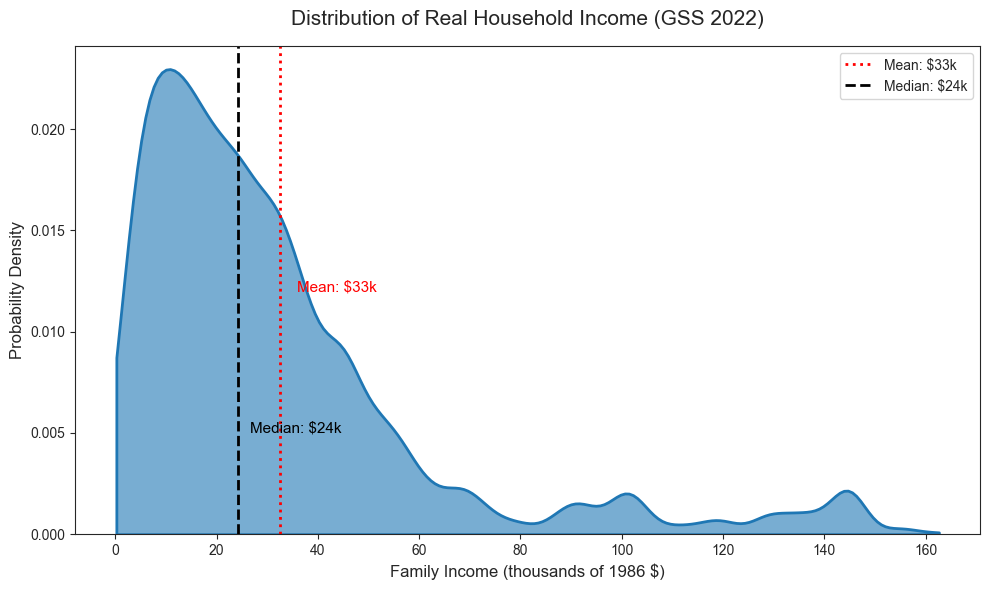

Mean income:   $32.5k
Median income: $24.1k
Difference:    $8.4k  (mean is pulled up by high earners)


In [3]:
sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(10, 6))

# Divide by 1000 so the x-axis reads in thousands of dollars
income_k = gss['realinc'] / 1000

sns.kdeplot(
    data=gss,
    x=income_k,
    ax=ax,
    fill=True,      # shade under the curve
    alpha=0.6,
    linewidth=2,
    cut=0           # do not extend the curve into negative income territory
)

# Calculate mean and median for annotation
mean_income   = income_k.mean().round(2)
median_income = income_k.median().round(2)

# Mean line (red dotted) -- pulled right by high earners
ax.axvline(mean_income,   color='red',   linestyle=':',  linewidth=2,
           label=f'Mean: ${mean_income:,.0f}k')
ax.text(mean_income * 1.1, 0.012, f'Mean: ${mean_income:,.0f}k', fontsize=11, color='red')

# Median line (black dashed) -- the true middle value
ax.axvline(median_income, color='black', linestyle='--', linewidth=2,
           label=f'Median: ${median_income:,.0f}k')
ax.text(median_income * 1.1, 0.005, f'Median: ${median_income:,.0f}k', fontsize=11, color='black')

ax.set_title('Distribution of Real Household Income (GSS 2022)', fontsize=15, pad=15)
ax.set_xlabel('Family Income (thousands of 1986 $)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean income:   ${mean_income:,.1f}k")
print(f"Median income: ${median_income:,.1f}k")
print(f"Difference:    ${mean_income - median_income:,.1f}k  (mean is pulled up by high earners)")

## 4. The Bootstrap Function

A general-purpose function that:
1. Resamples the data `num_iterations` times (with replacement)
2. Computes your chosen statistic on each resample
3. Builds a bootstrap distribution and reads off the 95% CI from its 2.5th and 97.5th percentiles
4. For the **mean** specifically, also overlays the traditional formula-based CI as a sanity check -- they should be very similar

In [4]:
def bootstrap_simulation(data, variable, statistic_func, num_iterations=1000):
    """
    Bootstrap confidence interval for any statistic.

    Parameters
    ----------
    data           : pd.DataFrame
    variable       : str   -- column name to bootstrap
    statistic_func : func  -- e.g. np.mean, np.median, np.std, or a lambda
    num_iterations : int   -- number of bootstrap resamples (default 1000)

    Returns
    -------
    bootstrap_stats_series : pd.Series  -- the full bootstrap distribution
    (ci_low, ci_high)      : tuple      -- 95% percentile CI bounds
    """

    # --- Prepare original data ---
    original_series = data[variable].dropna()
    original_size   = len(original_series)

    # --- Bootstrap loop ---
    # Each iteration: draw a same-size sample WITH replacement, compute the stat
    # 'replace=True' is the key -- it allows the same row to appear multiple times
    bootstrap_stats = [
        statistic_func(original_series.sample(n=original_size, replace=True))
        for _ in range(num_iterations)
    ]
    bootstrap_stats_series = pd.Series(bootstrap_stats)

    # --- Percentile CI ---
    # Take the 2.5th and 97.5th percentiles of the bootstrap distribution
    # This gives the central 95% of simulated values -- no formula required
    ci_low  = bootstrap_stats_series.quantile(0.025)
    ci_high = bootstrap_stats_series.quantile(0.975)

    # Stat on the original (un-resampled) data
    original_stat = statistic_func(original_series)

    # --- Plot ---
    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))

    # Histogram of the bootstrap distribution (the sampling distribution of our stat)
    sns.histplot(bootstrap_stats_series, ax=ax, kde=True, stat="density",
                 label=f"Bootstrap distribution of {statistic_func.__name__}")

    # Vertical line: stat on the original sample
    ax.axvline(original_stat, color='black', linestyle='-', linewidth=2,
               label=f'Original {statistic_func.__name__}: {original_stat:.2f}')

    # Red shaded band: 95% bootstrap CI
    ax.axvspan(ci_low, ci_high, color='red', alpha=0.2,
               label=f'95% Bootstrap CI ({ci_low:.2f} to {ci_high:.2f})')

    # For the mean only: overlay the formula-based CI as a sanity check
    # Formula: mean +/- t_critical * (sd / sqrt(n))
    # If bootstrapping is working correctly the two CIs should be very close
    if statistic_func == np.mean:
        se        = original_series.std() / np.sqrt(original_size)
        t_crit    = stats.t.ppf(0.975, df=original_size - 1)
        f_ci_low  = original_stat - t_crit * se
        f_ci_high = original_stat + t_crit * se
        ax.axvline(f_ci_low,  color='orange', linestyle=':', linewidth=2.5,
                   label=f'Formula CI ({f_ci_low:.2f} to {f_ci_high:.2f})')
        ax.axvline(f_ci_high, color='orange', linestyle=':', linewidth=2.5)

    ax.set_title(f'Bootstrap Distribution: "{variable}" -- {statistic_func.__name__}', fontsize=14)
    ax.set_xlabel(f'Simulated {statistic_func.__name__} values', fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Print summary ---
    print(f"Original {statistic_func.__name__}: {original_stat:.4f}")
    print(f"Bootstrap 95% CI: ({ci_low:.4f}, {ci_high:.4f})")
    if statistic_func == np.mean:
        print(f"Formula   95% CI: ({f_ci_low:.4f}, {f_ci_high:.4f})  <-- should be similar")
    print()

    return bootstrap_stats_series, (ci_low, ci_high)

print("Bootstrap function defined.")

Bootstrap function defined.


## 5. Bootstrap the GSS Income Variable

We run the bootstrap on four different statistics to show the technique works for any of them.

### 5a. Mean income

The orange dotted lines show the formula-based CI -- it should closely match the red bootstrap CI, which is a good validation that our function is correct.

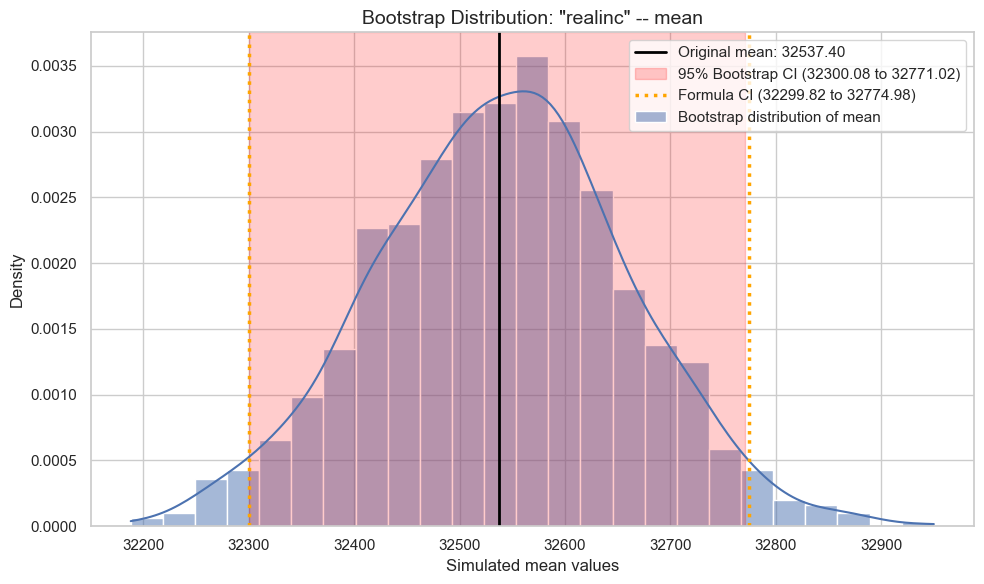

Original mean: 32537.4000
Bootstrap 95% CI: (32300.0777, 32771.0193)
Formula   95% CI: (32299.8164, 32774.9835)  <-- should be similar



In [5]:
mean_stats, mean_ci = bootstrap_simulation(
    data=gss,
    variable='realinc',
    statistic_func=np.mean,
    num_iterations=1000
)

### 5b. Median income

No simple formula exists for the median CI -- this is exactly where bootstrapping shines.

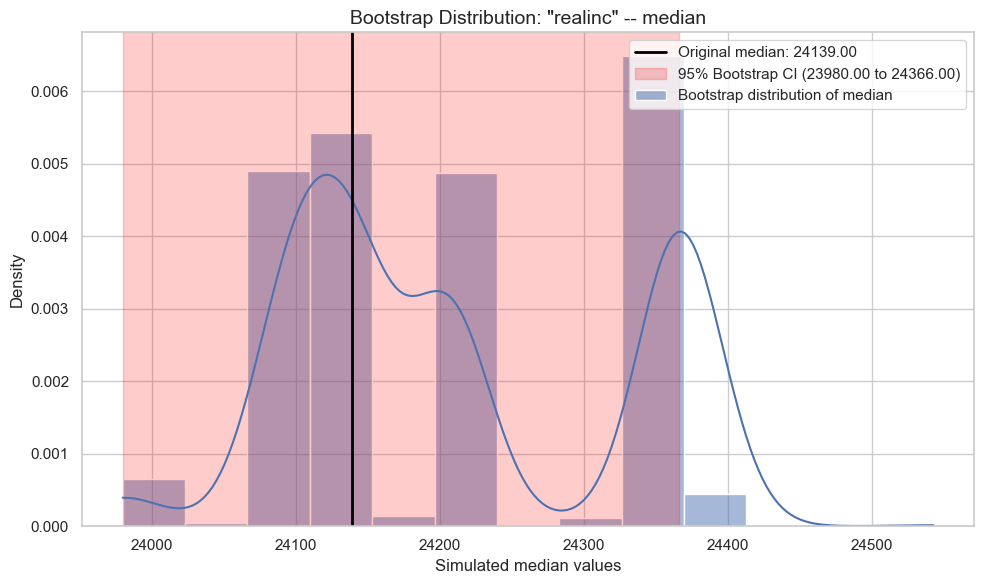

Original median: 24139.0000
Bootstrap 95% CI: (23980.0000, 24366.0000)



In [6]:
median_stats, median_ci = bootstrap_simulation(
    data=gss,
    variable='realinc',
    statistic_func=np.median,
    num_iterations=1000
)

### 5c. Standard deviation of income

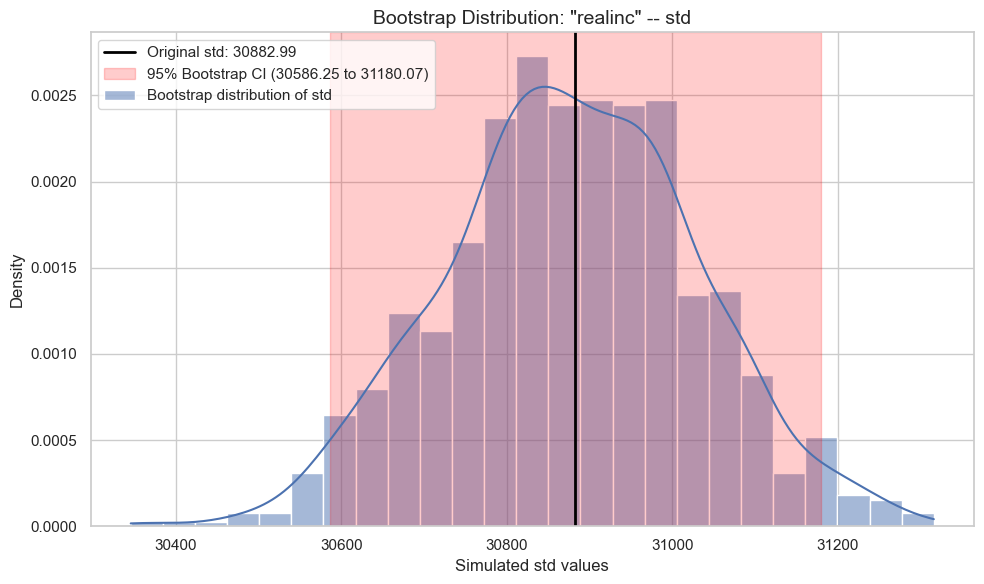

Original std: 30882.9882
Bootstrap 95% CI: (30586.2534, 31180.0710)



In [7]:
sd_stats, sd_ci = bootstrap_simulation(
    data=gss,
    variable='realinc',
    statistic_func=np.std,
    num_iterations=1000
)

### 5d. 10th percentile of income

A lambda function lets us pass any custom statistic -- here the 10th percentile.

```python
lambda x: np.percentile(x, 10)
# is equivalent to:
def calculate_10th_percentile(x):
    return np.percentile(x, 10)
```

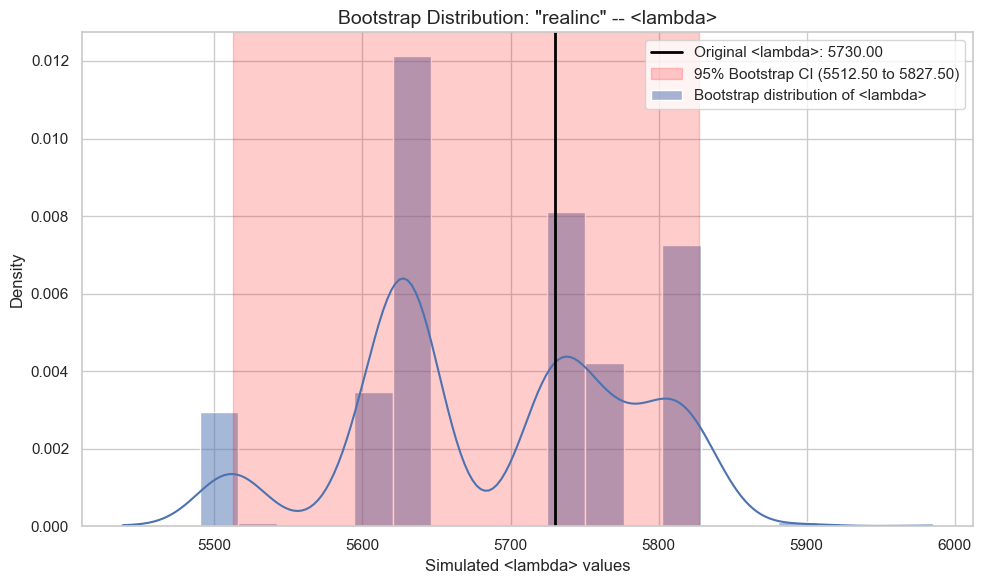

Original <lambda>: 5730.0000
Bootstrap 95% CI: (5512.5000, 5827.5000)



In [8]:
p10_stats, p10_ci = bootstrap_simulation(
    data=gss,
    variable='realinc',
    statistic_func=lambda x: np.percentile(x, 10),
    num_iterations=1000
)

## 6. Bootstrap on Movie Ratings

The same function works on any dataset. Here we compare mean ratings for Animation vs Documentary films.

In [9]:
movies = pd.read_csv('../data/movies.csv')
print(f"Movies loaded: {len(movies):,}")
movies['genre'].value_counts().head(10)

Movies loaded: 2,897


genre
Comedy         844
Action         719
Drama          484
Adventure      281
Crime          198
Biography      135
Horror         128
Animation       35
Fantasy         26
Documentary     25
Name: count, dtype: int64

### 6a. Animation

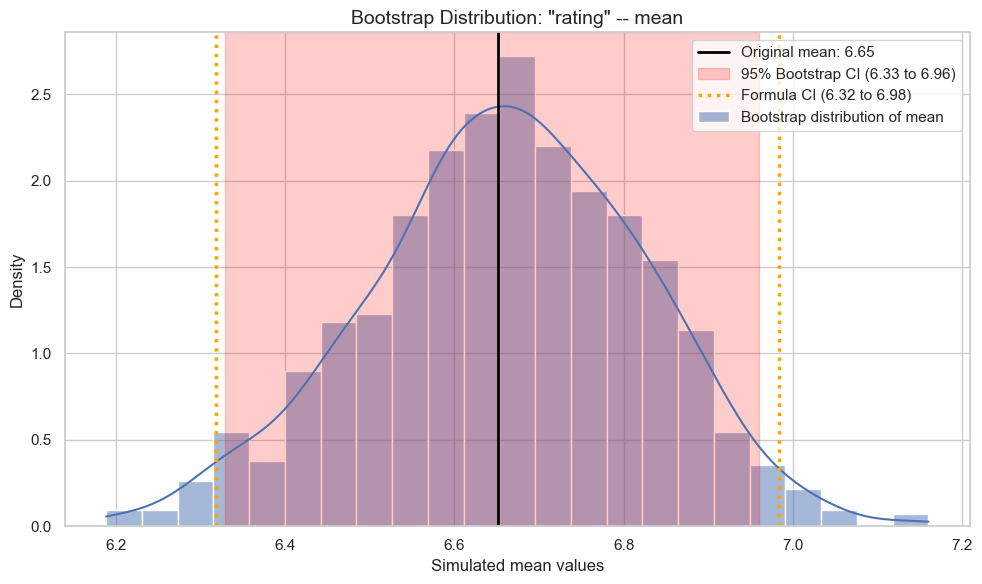

Original mean: 6.6514
Bootstrap 95% CI: (6.3285, 6.9600)
Formula   95% CI: (6.3189, 6.9840)  <-- should be similar



In [10]:
anim_stats, anim_ci = bootstrap_simulation(
    data=movies.query("genre == 'Animation'"),
    variable='rating',
    statistic_func=np.mean,
    num_iterations=1000
)

### 6b. Documentary

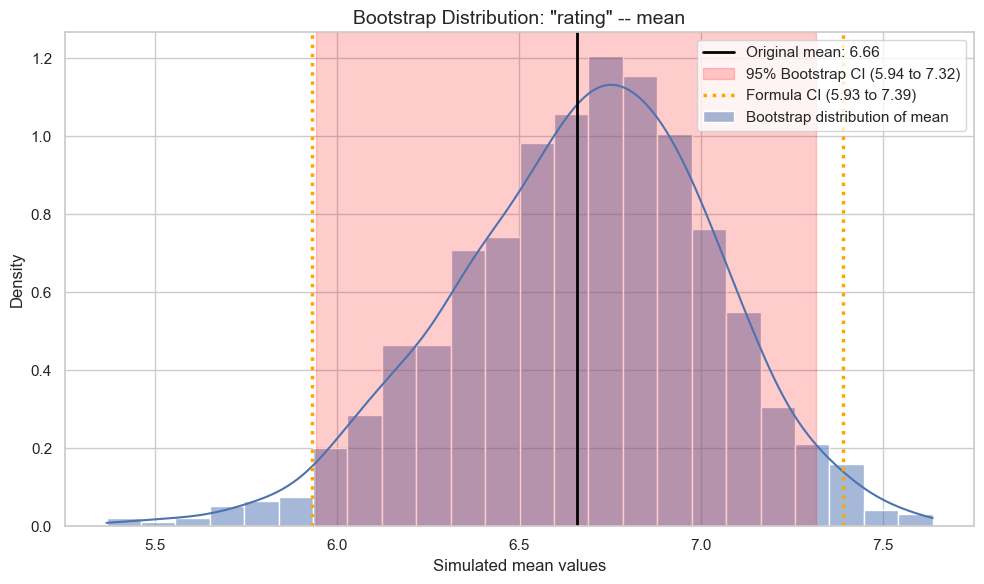

Original mean: 6.6600
Bootstrap 95% CI: (5.9438, 7.3160)
Formula   95% CI: (5.9308, 7.3892)  <-- should be similar



In [11]:
doc_stats, doc_ci = bootstrap_simulation(
    data=movies.query("genre == 'Documentary'"),
    variable='rating',
    statistic_func=np.mean,
    num_iterations=1000
)

## 7. Comparing the Two Genres

Print both CIs side by side to see if they overlap -- overlapping CIs suggest the difference in mean rating may not be statistically significant.

In [12]:
print("Genre            Mean CI (95% bootstrap)")
print("-" * 45)
print(f"Animation        ({anim_ci[0]:.3f}, {anim_ci[1]:.3f})")
print(f"Documentary      ({doc_ci[0]:.3f}, {doc_ci[1]:.3f})")
print()
if anim_ci[1] < doc_ci[0] or doc_ci[1] < anim_ci[0]:
    print("CIs do NOT overlap -- the difference in mean rating is likely real.")
else:
    print("CIs overlap -- cannot confidently conclude a difference in mean rating.")

Genre            Mean CI (95% bootstrap)
---------------------------------------------
Animation        (6.329, 6.960)
Documentary      (5.944, 7.316)

CIs overlap -- cannot confidently conclude a difference in mean rating.
